# Information theory of matrix completion — experiments

Companion notebook to the post. The experiments verify the closed-form completion
capacities against the entropy computation, and illustrate the structured
degrees-of-freedom counts.

The completion capacity of the i.i.d.-column model is
$C = \sum_\ell H(X_\ell) / H(X_1,\dots,X_k)$, the average number of entries one
observation resolves; the minimum number of observed entries is $m = kn/C$.

This notebook uses small self-contained reimplementations of the capacity
functionals. The full library is in the
[project repository](https://github.com/mmkuznecov/ITMatrixCompletion).

In [1]:
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- site theme -----------------------------------------------------------
BG, PANEL, LINE = "#0e1116", "#151a21", "#222a35"
FG, MUTED, ACCENT, ACCENT2 = "#d7dde6", "#8a94a3", "#4aa3ff", "#e0a458"
mpl.rcParams.update({
    "figure.facecolor": PANEL, "axes.facecolor": PANEL, "savefig.facecolor": PANEL,
    "axes.edgecolor": LINE, "axes.labelcolor": FG, "text.color": FG,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": LINE,
    "axes.grid": True, "grid.linewidth": 0.6, "grid.alpha": 0.35,
    "font.family": "monospace", "font.size": 11, "figure.dpi": 120,
    "axes.titlesize": 12, "legend.frameon": False, "legend.labelcolor": FG,
})
def style(ax):
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(LINE)
    return ax
rng = np.random.default_rng(0)

## Capacity functionals

The entropy of a discrete distribution, the marginals of a joint pmf array, and the
i.i.d. completion capacity.

In [2]:
LOG2 = np.log(2.0)

def H(p):
    p = np.asarray(p, float).ravel(); p = p[p > 0]
    return float(-np.sum(p * np.log(p)) / LOG2)

def marginal(joint, axis):
    other = tuple(i for i in range(joint.ndim) if i != axis)
    return joint.sum(axis=other)

def capacity(joint):
    joint = np.asarray(joint, float); k = joint.ndim
    S = sum(H(marginal(joint, l)) for l in range(k))
    Hj = H(joint)
    return dict(C=(np.inf if Hj < 1e-12 else S / Hj), S=S, Hjoint=Hj, TC=S - Hj)

# quick check on a 2x2 joint
joint = np.array([[0.4, 0.1], [0.1, 0.4]])
print(capacity(joint))

{'C': 1.1614886858157845, 'S': 2.0, 'Hjoint': 1.7219280948873625, 'TC': 0.27807190511263746}


## 1. The three exact discrete cases

Independence gives $C = 1$, identical rows give $C = k$, and a rank-$r$ binary linear
code gives $C = k/r$.

In [3]:
def independent(marginals):
    j = marginals[0].astype(float)
    for m in marginals[1:]: j = np.multiply.outer(j, m)
    return j

def fully_correlated(a, k):
    j = np.zeros((a,) * k)
    for s in range(a): j[(s,) * k] = 1.0 / a
    return j

def linear_code(G):
    G = np.asarray(G) % 2; k, r = G.shape; j = np.zeros((2,) * k)
    for u in product((0, 1), repeat=r):
        x = tuple((G @ np.array(u)) % 2); j[x] += 1.0
    return j / j.sum()

# independence
ind = independent([rng.dirichlet(np.ones(3)) for _ in range(4)])
print(f"independent (k=4):   C = {capacity(ind)['C']:.6f}   (expect 1)")

# identical rows
print(f"identical rows (k=5): C = {capacity(fully_correlated(2, 5))['C']:.6f}   (expect 5)")

# rank-r code
for k, r in [(6, 2), (8, 3), (10, 1)]:
    # random full-rank generator with no zero row
    while True:
        G = rng.integers(0, 2, size=(k, r))
        if not (G.sum(1) == 0).any() and np.linalg.matrix_rank(G % 2) == r:
            break
    C = capacity(linear_code(G))['C']
    print(f"rank-{r} code (k={k}):   C = {C:.6f}   (expect k/r = {k/r:.4f})")

independent (k=4):   C = 1.000000   (expect 1)
identical rows (k=5): C = 5.000000   (expect 5)
rank-2 code (k=6):   C = 3.000000   (expect k/r = 3.0000)
rank-3 code (k=8):   C = 2.666667   (expect k/r = 2.6667)
rank-1 code (k=10):   C = 10.000000   (expect k/r = 10.0000)


## 2. The common-bit model

All rows share a latent bit through independent $\mathrm{Bern}(q)$ noise. The capacity
slides from $k$ at $q = 0$ to $1$ at $q = 1/2$: redundancy that is noisy rather than
deterministic.

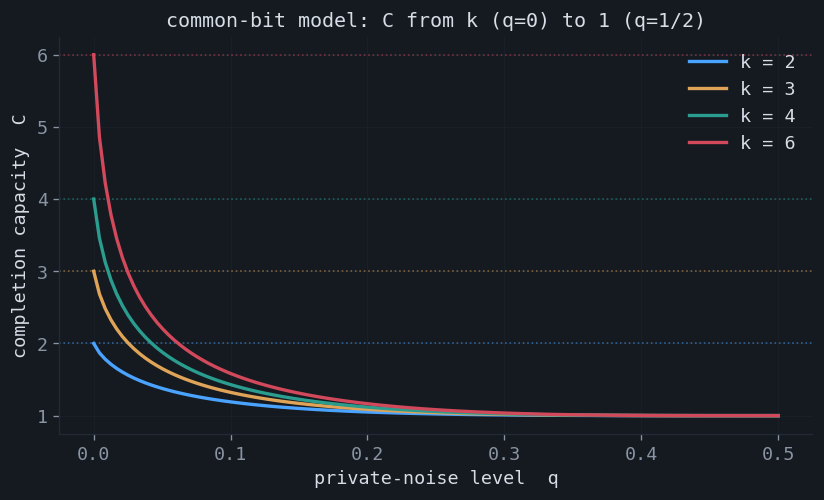

k=4: C(q=0) = 4.0000,  C(q=0.5) = 1.0000


In [4]:
def common_bit(k, q):
    j = np.zeros((2,) * k)
    for b in (0, 1):
        for z in product((0, 1), repeat=k):
            x = tuple(b ^ zl for zl in z)
            pz = np.prod([q if zl else (1 - q) for zl in z])
            j[x] += 0.5 * pz
    return j

ks = [2, 3, 4, 6]; qs = np.linspace(0, 0.5, 120)
fig, ax = plt.subplots(figsize=(7, 4.3))
for c, k in zip([ACCENT, ACCENT2, "#2a9d8f", "#d1495b"], ks):
    C = [capacity(common_bit(k, q))['C'] for q in qs]
    ax.plot(qs, C, color=c, lw=2, label=f"k = {k}")
    ax.axhline(k, color=c, ls=":", lw=1, alpha=0.5)
ax.set_xlabel("private-noise level  q"); ax.set_ylabel("completion capacity  C")
ax.set_title("common-bit model: C from k (q=0) to 1 (q=1/2)"); ax.legend(); style(ax)
plt.tight_layout(); plt.show()
print(f"k=4: C(q=0) = {capacity(common_bit(4,0))['C']:.4f},  C(q=0.5) = {capacity(common_bit(4,0.5))['C']:.4f}")

## 3. Noisy entries through a binary symmetric channel

For a rank-$r$ code observed through a BSC with crossover $\delta$, the capacity is
$C = k(1 - h(\delta))/r$, degrading the noiseless $k/r$ by the channel factor.

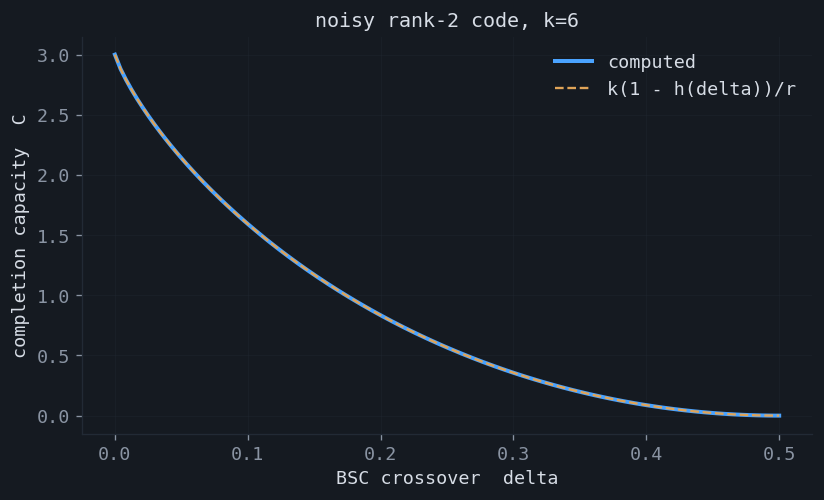

max |computed - formula| = 6.66e-16


In [5]:
def hbin(d):
    return 0.0 if d in (0.0, 1.0) else -d*np.log2(d) - (1-d)*np.log2(1-d)

def bsc(delta):
    return np.array([[1-delta, delta], [delta, 1-delta]])

def capacity_noisy(joint, channel):
    joint = np.asarray(joint, float); k = joint.ndim; Hj = H(joint); Isum = 0.0
    for l in range(k):
        px = marginal(joint, l); W = channel(l)
        py = (px[:, None] * W).sum(0)
        HYgX = sum(px[x] * H(W[x]) for x in range(len(px)))
        Isum += H(py) - HYgX
    return Isum / Hj

k, r = 6, 2
while True:
    G = rng.integers(0, 2, size=(k, r))
    if not (G.sum(1) == 0).any() and np.linalg.matrix_rank(G % 2) == r: break
joint = linear_code(G)
deltas = np.linspace(0, 0.5, 120)
C = [capacity_noisy(joint, lambda l, d=d: bsc(d)) for d in deltas]
pred = [k*(1 - hbin(d))/r for d in deltas]

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(deltas, C, color=ACCENT, lw=2.4, label="computed")
ax.plot(deltas, pred, color=ACCENT2, lw=1.4, ls="--", label="k(1 - h(delta))/r")
ax.set_xlabel("BSC crossover  delta"); ax.set_ylabel("completion capacity  C")
ax.set_title(f"noisy rank-{r} code, k={k}"); ax.legend(); style(ax)
plt.tight_layout(); plt.show()
print(f"max |computed - formula| = {np.max(np.abs(np.array(C) - np.array(pred))):.2e}")

## 4. Quantized Gaussian: capacity recovers the rank

For an exactly rank-$r$ covariance, the quantized capacity gives $k/C \to r$ as the
bin width shrinks. For a full-rank covariance, $C \to 1$.

In [6]:
def gaussian_capacity_quantized(Sigma, Delta):
    eigs = np.clip(np.linalg.eigvalsh(Sigma), 0, None)
    def qent(lams):
        c = 0.5*np.log2(2*np.pi*np.e*np.clip(lams, 1e-300, None)) - np.log2(Delta)
        return np.sum(np.maximum(c, 0.0))
    S = qent(np.clip(np.diag(Sigma), 1e-300, None)); Hj = qent(eigs)
    return np.inf if Hj < 1e-12 else S / Hj

for k, r in [(6, 2), (8, 3), (10, 1)]:
    F = rng.standard_normal((k, r)); Sig = F @ F.T   # exactly rank r
    C = gaussian_capacity_quantized(Sig, 1e-5)
    print(f"rank-{r} Gaussian (k={k}): k/C = {k/C:.4f} -> rank {round(k/C)}")

Sig_full = (1-0.6)*np.eye(5) + 0.6*np.ones((5,5))    # full rank
print(f"full-rank Gaussian (k=5): C = {gaussian_capacity_quantized(Sig_full, 1e-5):.4f}  (expect ~1)")

rank-2 Gaussian (k=6): k/C = 2.0792 -> rank 2
rank-3 Gaussian (k=8): k/C = 3.1222 -> rank 3
rank-1 Gaussian (k=10): k/C = 1.1418 -> rank 1
full-rank Gaussian (k=5): C = 1.0192  (expect ~1)


## 5. Structured degrees of freedom and the dichotomy

Capacity as the dimension ratio $C = N / \dim\mathcal{F}$ for structured families.
Linear-redundancy families diverge with $k$; involutive families converge to $2$.

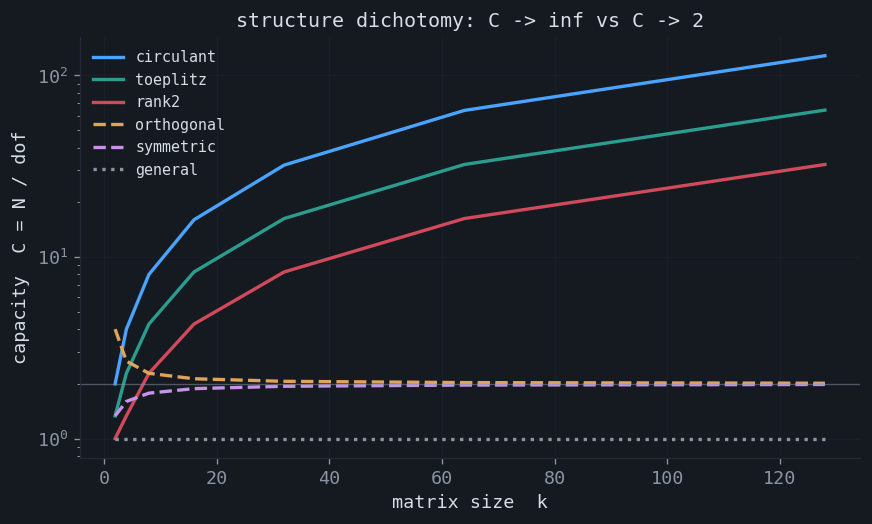

k=64:  circulant C = 64.0  symmetric C = 1.9692


In [7]:
def family(name, k):
    n = k
    if name == "general":   N, d = k*n, k*n
    elif name == "diagonal": N, d = k, k
    elif name == "rank2":   N, d = k*n, 2*(k+n-2)
    elif name == "toeplitz": N, d = k*n, k+n-1
    elif name == "circulant": N, d = k*k, k
    elif name == "symmetric": N, d = k*k, k*(k+1)//2
    elif name == "orthogonal": N, d = k*k, k*(k-1)//2
    return N / d

ks = np.array([2, 4, 8, 16, 32, 64, 128])
fig, ax = plt.subplots(figsize=(7.4, 4.5))
families = [("circulant", ACCENT, "-"), ("toeplitz", "#2a9d8f", "-"),
            ("rank2", "#d1495b", "-"), ("orthogonal", ACCENT2, "--"),
            ("symmetric", "#c792ea", "--"), ("general", MUTED, ":")]
for name, c, ls in families:
    ax.plot(ks, [family(name, int(k)) for k in ks], ls, color=c, lw=2, label=name)
ax.axhline(2, color=MUTED, lw=0.8, alpha=0.5)
ax.set_yscale("log"); ax.set_xlabel("matrix size  k"); ax.set_ylabel("capacity  C = N / dof")
ax.set_title("structure dichotomy: C -> inf vs C -> 2"); ax.legend(fontsize=9); style(ax)
plt.tight_layout(); plt.show()
print("k=64:  circulant C =", family("circulant", 64), " symmetric C =", round(family("symmetric", 64), 4))

## Summary

- The capacity is $C = S / H_{\text{joint}}$, monotone in the redundancy
  $\mathrm{TC} = S - H_{\text{joint}}$.
- Independence gives $C = 1$, identical rows give $C = k$, a rank-$r$ code gives
  $C = k/r$, all verified to machine precision.
- Noisy observation scales the capacity by the channel factor $1 - h(\delta)$.
- For continuous (Gaussian) entries, $C > 1$ requires exact rank deficiency.
- For structured matrices, $C = N/\dim\mathcal{F}$ splits into linear-redundancy
  families ($C \to \infty$) and involutive families ($C \to 2$).